# Spectral Snapshot Compressive Imaging (PnP-CASSI)

This notebook demonstrates the reconstruction of hyperspectral images from a single compressed CASSI measurement using the Plug-and-Play (PnP) framework with a deep CNN denoiser prior.

**Reference:** Zheng et al., "Deep plug-and-play priors for spectral snapshot compressive imaging," *Photon. Res.* 9, B18-B29 (2021)

**Contents:**
1. Load precomputed results and ground truth
2. Compressed measurement and pseudo-RGB preview
3. Ground truth — all 31 spectral bands (400–700 nm)
4. Reconstruction (GAP-HSICNN) — all 31 spectral bands
5. Side-by-side comparison and metrics
6. Pseudo-RGB comparison
7. (Optional) Run full reconstruction from scratch

In [1]:
import os
import sys
import json
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
%matplotlib inline

# Add project root to path
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

from src.preprocessing import load_meta_data, load_data, build_mask_3d
from src.physics_model import shift_back
from src.visualization import psnr, calculate_ssim

## 1. Load Data and Precomputed Results

In [2]:
# Paths
data_dir = '../data'
ref_dir = '../evaluation/reference_outputs'
eval_dir = '../evaluation'
datname = 'kaist_crop256_01'

# Load metadata
meta = load_meta_data(os.path.join(data_dir, 'meta_data.json'))
r, c, nC, step = meta['r'], meta['c'], meta['nC'], meta['step']
wl_start, wl_step = meta['wavelength_start_nm'], meta['wavelength_step_nm']
print(f"Scene: {r}x{c}, {nC} bands ({wl_start}-{meta['wavelength_end_nm']}nm, {wl_step}nm step)")

# Load ground truth from npz
_, _, truth = load_data(
    os.path.join(data_dir, 'raw_data.npz'),
    os.path.join(data_dir, 'ground_truth.npz'),
)
print(f"Ground truth shape: {truth.shape}, range: [{truth.min():.4f}, {truth.max():.4f}]")

# Load precomputed reconstruction
recon = sio.loadmat(os.path.join(ref_dir, f'{datname}_result.mat'))['img']
print(f"Reconstruction shape: {recon.shape}")

# Load metrics
with open(os.path.join(eval_dir, 'metrics.json')) as f:
    metrics = json.load(f)
baseline = metrics['baseline'][0]
print(f"\nBaseline method: {baseline['method']}")
print(f"NCC vs reference: {baseline['ncc_vs_ref']:.4f}")
print(f"NRMSE vs reference: {baseline['nrmse_vs_ref']:.4f}")

Scene: 256x256, 31 bands (400-700nm, 10nm step)
Ground truth shape: (256, 256, 31), range: [0.0190, 0.5083]
Reconstruction shape: (256, 256, 31)

Baseline method: GAP-HSICNN (GAP with HSI-SDeCNN plug-and-play denoiser, 20 outer iterations)
NCC vs reference: 0.9949
NRMSE vs reference: 0.0217


## 2. Compressed Measurement and Pseudo-RGB Preview

In SD-CASSI, the 3D spectral cube is modulated by a binary coded aperture mask, dispersed by a prism (each channel shifted by `d_k` pixels), and integrated onto a single 2D detector. The measurement width is `W + (nC-1)*step` pixels to accommodate the maximum spectral shift.

Measurement shape: (256, 286)
3D sensing matrix (Phi) shape: (256, 286, 31)


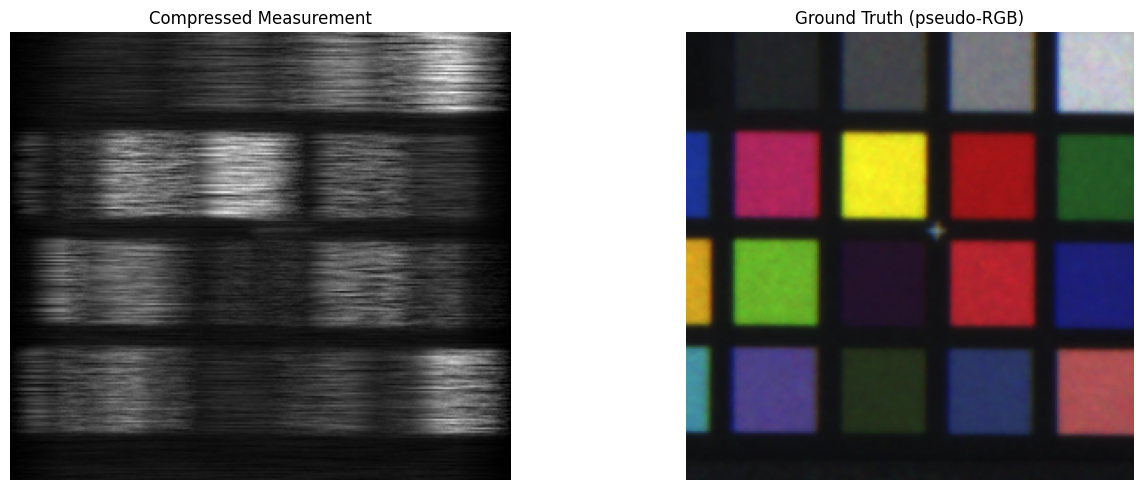

In [3]:
# Load measurement and mask from npz, build 3D sensing matrix
meas, mask2d, _ = load_data(
    os.path.join(data_dir, 'raw_data.npz'),
    os.path.join(data_dir, 'ground_truth.npz'),
)
mask_3d = build_mask_3d(mask2d, r, c, nC, step)
print(f"Measurement shape: {meas.shape}")
print(f"3D sensing matrix (Phi) shape: {mask_3d.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(meas, cmap='gray')
axes[0].set_title('Compressed Measurement')
axes[0].axis('off')

# Show an RGB-like composite of ground truth (bands ~20,14,5 for R,G,B)
rgb = np.stack([truth[:,:,20], truth[:,:,14], truth[:,:,5]], axis=-1)
rgb = rgb / rgb.max()
axes[1].imshow(rgb)
axes[1].set_title('Ground Truth (pseudo-RGB)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Ground Truth - All 31 Spectral Bands (400-700nm)

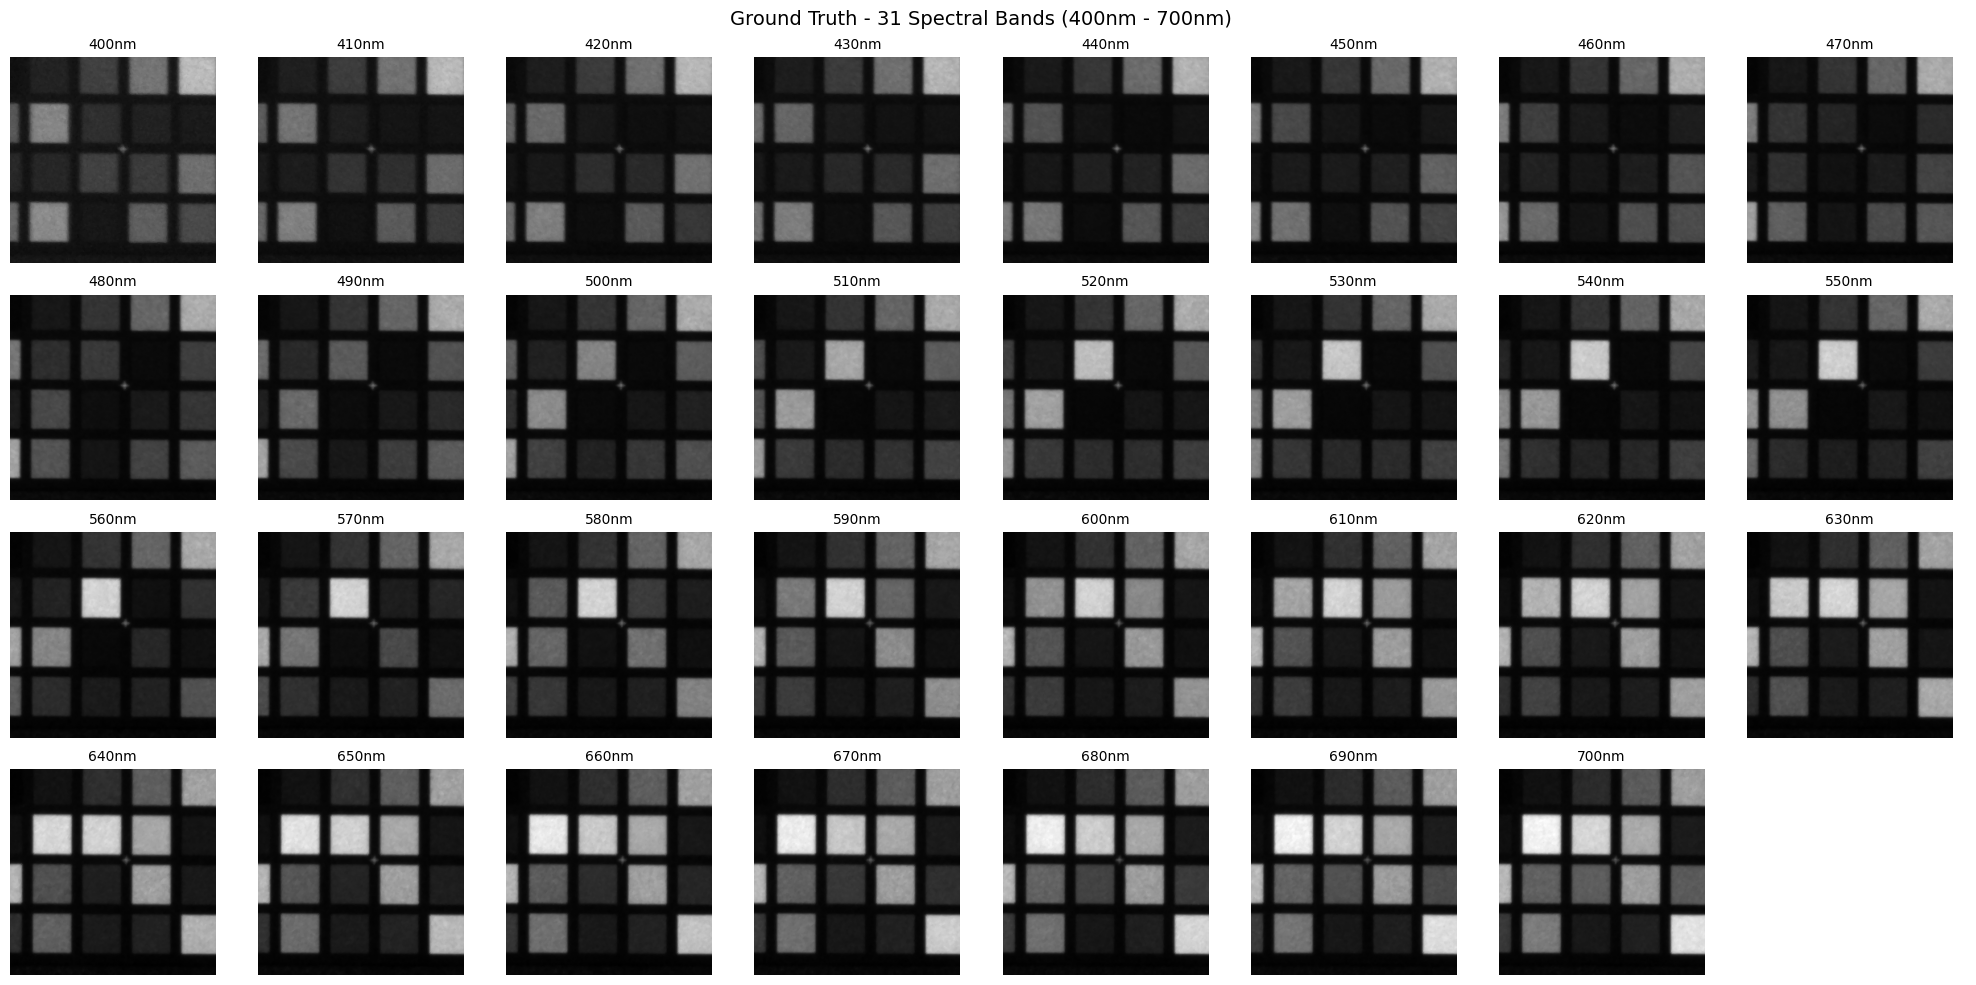

In [4]:
ncols = 8
nrows = 4
vmin, vmax = truth.min(), truth.max()

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))
for i in range(nC):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    ax.imshow(truth[:,:,i], cmap=plt.cm.gray, vmin=vmin, vmax=vmax)
    ax.set_title(f'{wl_start + i*wl_step}nm', fontsize=10)
    ax.axis('off')
axes[3, 7].axis('off')
plt.suptitle('Ground Truth - 31 Spectral Bands (400nm - 700nm)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Reconstruction (GAP-HSICNN) - All 31 Spectral Bands

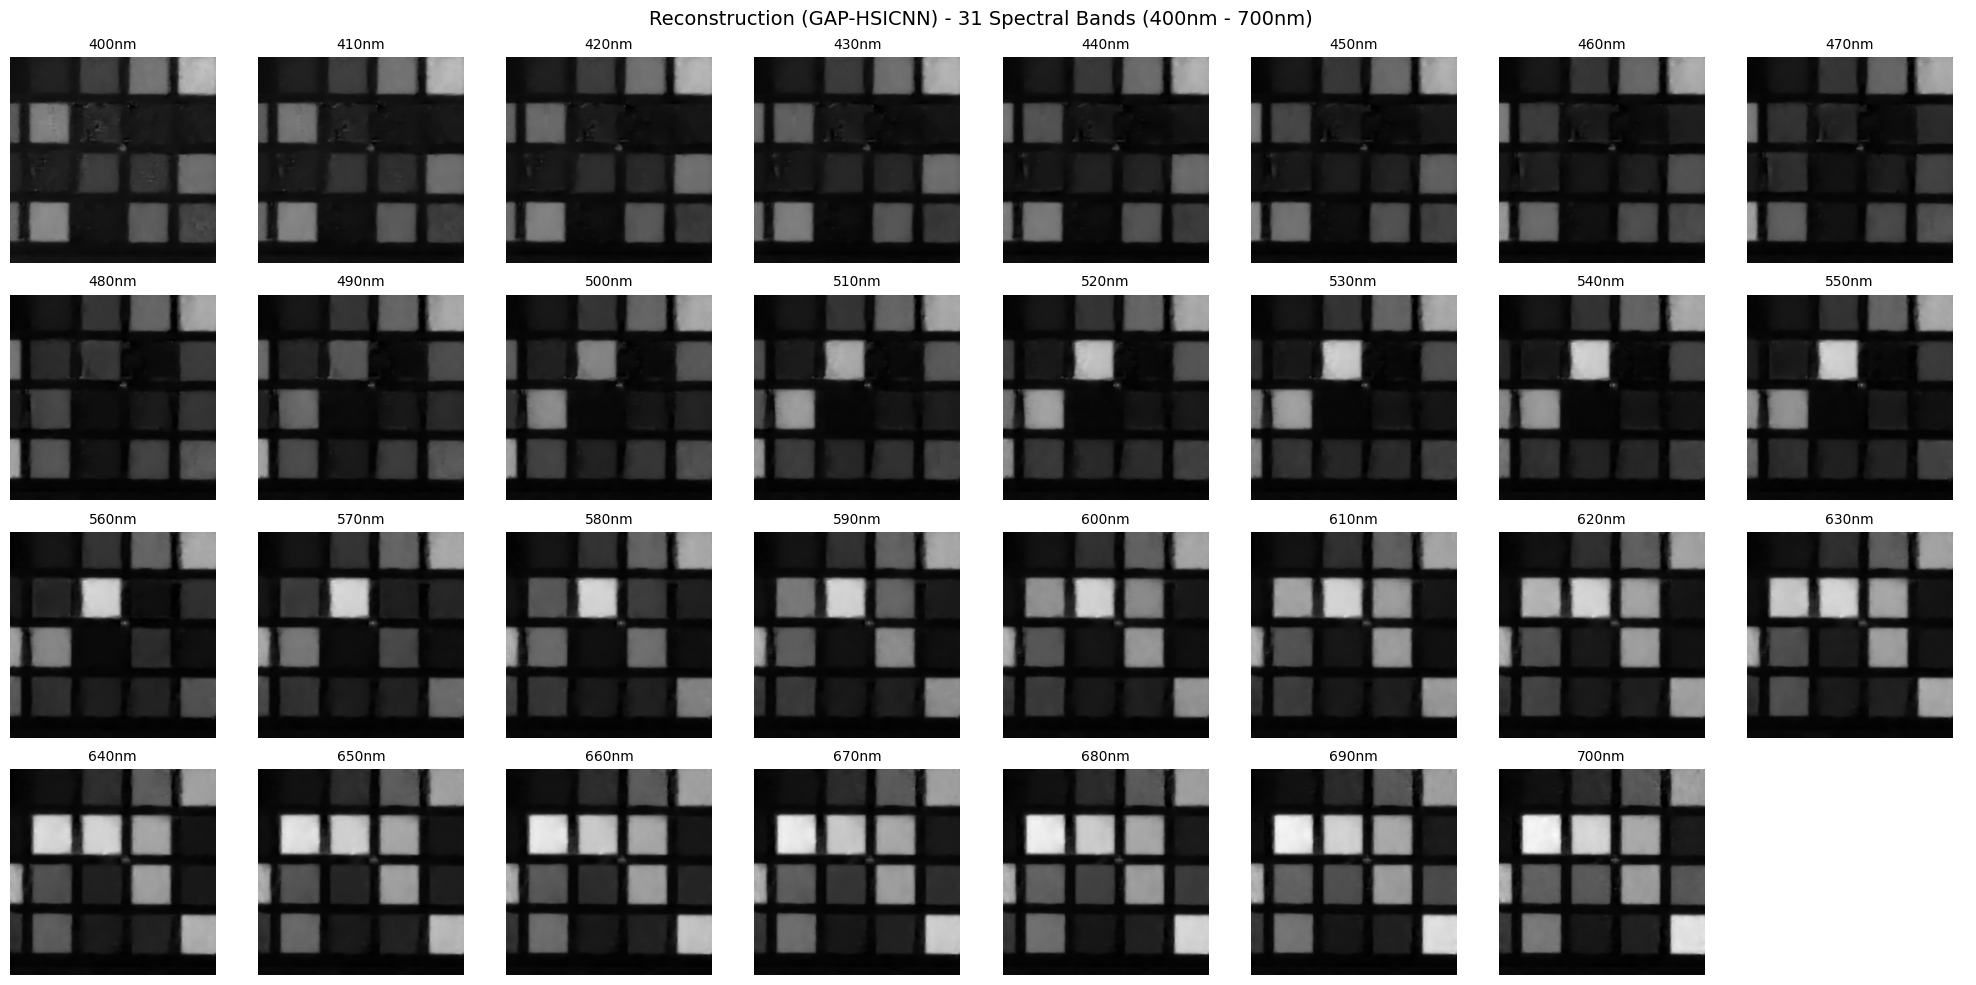

In [5]:
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 10))
for i in range(nC):
    row, col = divmod(i, ncols)
    ax = axes[row, col]
    ax.imshow(recon[:,:,i], cmap=plt.cm.gray, vmin=vmin, vmax=vmax)
    ax.set_title(f'{wl_start + i*wl_step}nm', fontsize=10)
    ax.axis('off')
axes[3, 7].axis('off')
plt.suptitle('Reconstruction (GAP-HSICNN) - 31 Spectral Bands (400nm - 700nm)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Side-by-Side Comparison and Metrics

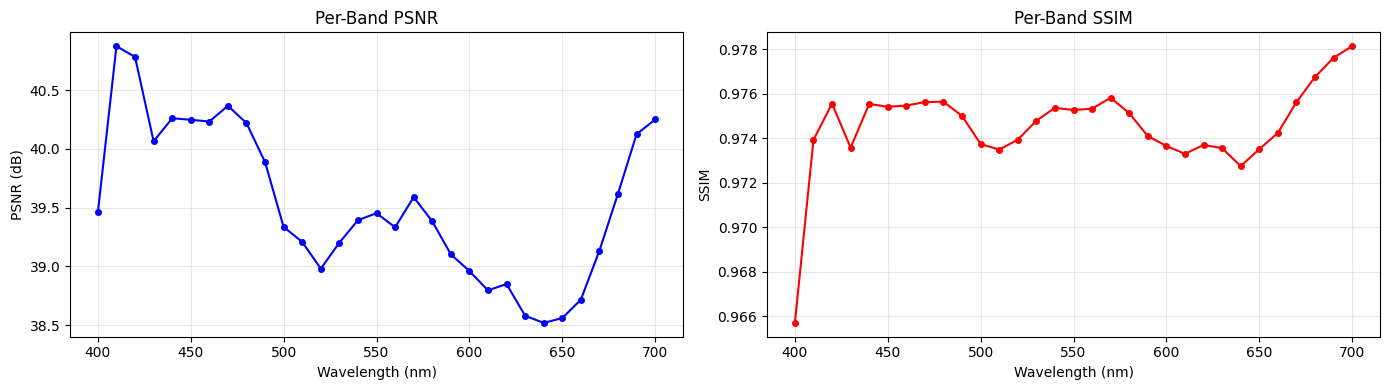

Overall PSNR: 39.48 dB
Overall SSIM: 0.9746
Mean per-band PSNR: 39.53 dB
Mean per-band SSIM: 0.9746

NCC vs ground truth: 0.9949
NRMSE vs ground truth: 0.0217


In [6]:
from src.visualization import ssim as ssim_single

# Compute per-band PSNR and SSIM
band_psnr = [psnr(truth[:,:,i], recon[:,:,i]) for i in range(nC)]
band_ssim = [ssim_single(truth[:,:,i], recon[:,:,i]) for i in range(nC)]
wavelengths = [wl_start + i * wl_step for i in range(nC)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(wavelengths, band_psnr, 'b-o', markersize=4)
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('PSNR (dB)')
ax1.set_title('Per-Band PSNR')
ax1.grid(True, alpha=0.3)

ax2.plot(wavelengths, band_ssim, 'r-o', markersize=4)
ax2.set_xlabel('Wavelength (nm)')
ax2.set_ylabel('SSIM')
ax2.set_title('Per-Band SSIM')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Overall metrics
overall_psnr = psnr(truth, recon)
overall_ssim = calculate_ssim(truth, recon)
print(f"Overall PSNR: {overall_psnr:.2f} dB")
print(f"Overall SSIM: {overall_ssim:.4f}")
print(f"Mean per-band PSNR: {np.mean(band_psnr):.2f} dB")
print(f"Mean per-band SSIM: {np.mean(band_ssim):.4f}")
print(f"\nNCC vs ground truth: {baseline['ncc_vs_ref']:.4f}")
print(f"NRMSE vs ground truth: {baseline['nrmse_vs_ref']:.4f}")

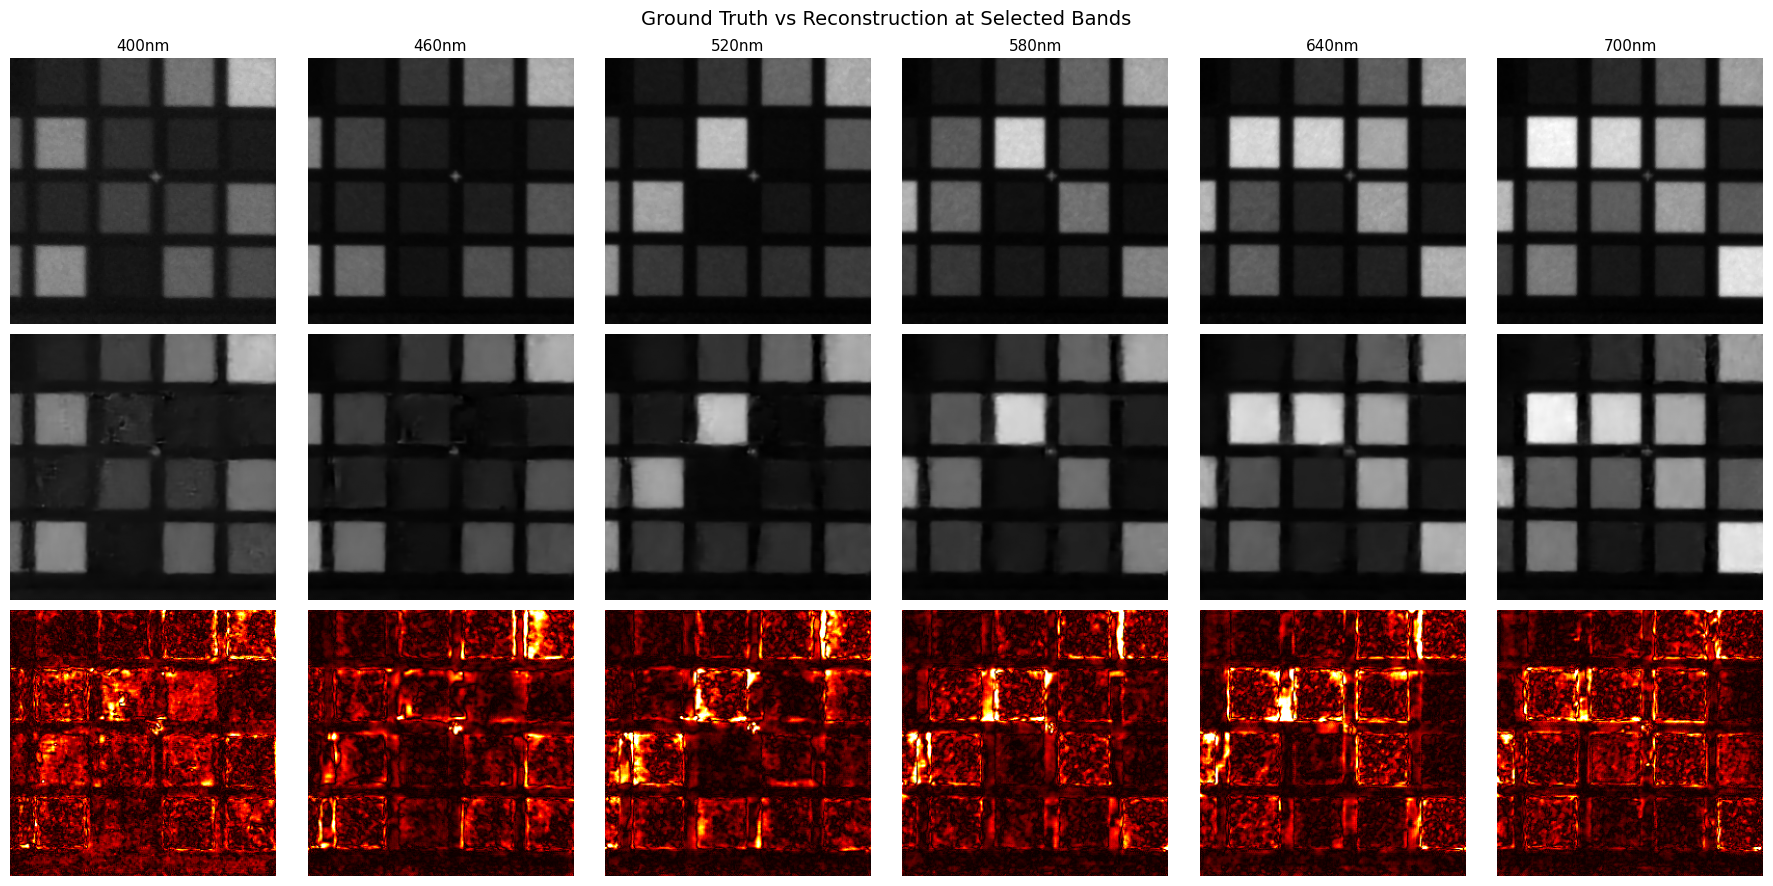

In [7]:
# Select 6 representative bands for detailed comparison
bands_to_show = [0, 6, 12, 18, 24, 30]
fig, axes = plt.subplots(3, len(bands_to_show), figsize=(18, 9))

for j, b in enumerate(bands_to_show):
    wl = wl_start + b * wl_step
    axes[0, j].imshow(truth[:,:,b], cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, j].set_title(f'{wl}nm', fontsize=11)
    axes[0, j].axis('off')

    axes[1, j].imshow(recon[:,:,b], cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, j].axis('off')

    diff = np.abs(truth[:,:,b] - recon[:,:,b])
    axes[2, j].imshow(diff, cmap='hot', vmin=0, vmax=0.05)
    axes[2, j].axis('off')

axes[0, 0].set_ylabel('Ground Truth', fontsize=11)
axes[1, 0].set_ylabel('Reconstruction', fontsize=11)
axes[2, 0].set_ylabel('|Error|', fontsize=11)
plt.suptitle('Ground Truth vs Reconstruction at Selected Bands', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Pseudo-RGB Comparison

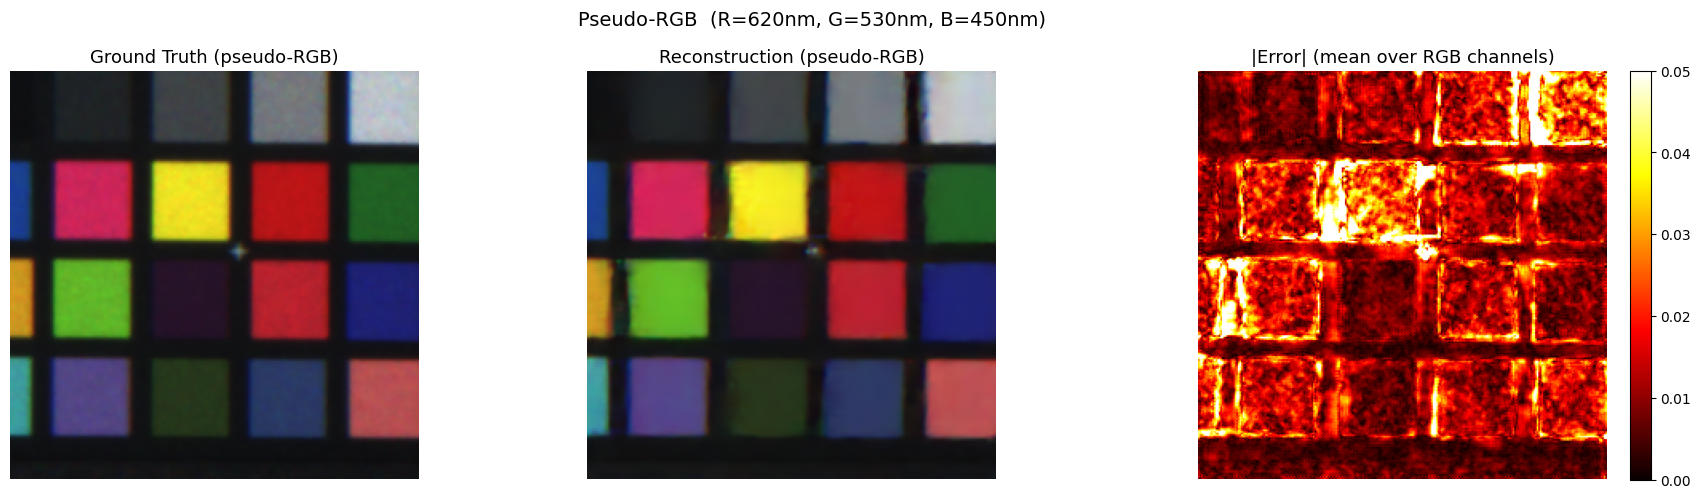

In [8]:
# Pseudo-RGB composite: use bands near 620nm (R), 530nm (G), 450nm (B)
# With wl_start=400nm and wl_step=10nm: band 22=620nm, band 13=530nm, band 5=450nm
b_r, b_g, b_b = 22, 13, 5

def make_rgb(cube):
    rgb = np.stack([cube[:, :, b_r], cube[:, :, b_g], cube[:, :, b_b]], axis=-1)
    rgb = np.clip(rgb / rgb.max(), 0, 1)
    return rgb

rgb_gt    = make_rgb(truth)
rgb_recon = make_rgb(recon)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(rgb_gt)
axes[0].set_title('Ground Truth (pseudo-RGB)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(rgb_recon)
axes[1].set_title('Reconstruction (pseudo-RGB)', fontsize=13)
axes[1].axis('off')

diff_rgb = np.abs(rgb_gt.astype(np.float64) - rgb_recon.astype(np.float64))
im = axes[2].imshow(diff_rgb.mean(axis=-1), cmap='hot', vmin=0, vmax=0.05)
axes[2].set_title('|Error| (mean over RGB channels)', fontsize=13)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

wl_labels = [f'{wl_start + b*wl_step}nm' for b in [b_r, b_g, b_b]]
fig.suptitle(f'Pseudo-RGB  (R={wl_labels[0]}, G={wl_labels[1]}, B={wl_labels[2]})', fontsize=14)
plt.tight_layout()
plt.show()

## 7. (Optional) Run Full Reconstruction from Scratch

Uncomment the cell below to run the full GAP-HSICNN reconstruction pipeline. **Requires a CUDA GPU** and takes ~60 seconds on an A100.

In [9]:
# Run all cells above first to define meas, mask_3d, truth, meta, ref_dir.
# This cell takes ~60 seconds on a GPU (CPU fallback will be much slower).

import time
from src.solvers import gap_denoise

checkpoint_path = os.path.join(ref_dir, 'deep_denoiser.pth')
solver_cfg = meta['solver_config']['GAP']

print('Running GAP-HSICNN reconstruction...')
begin_time = time.time()
vgap, psnr_all, ssim_all = gap_denoise(
    meas, mask_3d,
    _lambda=solver_cfg['lambda'],
    accelerate=solver_cfg['accelerate'],
    iter_max=solver_cfg['iter_max'],
    sigma=solver_cfg['sigma'],
    tv_iter_max=solver_cfg['tv_iter_max'],
    X_orig=truth,
    checkpoint_path=checkpoint_path,
)
elapsed = time.time() - begin_time
vrecon_new = shift_back(vgap, step=1)

new_psnr = psnr(truth, vrecon_new)
new_ssim = calculate_ssim(truth, vrecon_new)
print(f'GAP-HSICNN: PSNR {new_psnr:.2f} dB, SSIM {new_ssim:.4f}, time {elapsed:.1f}s')

Running GAP-HSICNN reconstruction...


  GAP-HSICNN iteration   1, PSNR -1.69 dB, SSIM -0.0129


  GAP-HSICNN iteration   2, PSNR 4.18 dB, SSIM -0.0713


  GAP-HSICNN iteration   3, PSNR 11.06 dB, SSIM -0.1882


  GAP-HSICNN iteration   4, PSNR 17.89 dB, SSIM 0.1927


...

  GAP-HSICNN iteration  121, PSNR 39.02 dB, SSIM 0.9728


  GAP-HSICNN iteration  122, PSNR 39.20 dB, SSIM 0.9735


  GAP-HSICNN iteration  123, PSNR 39.37 dB, SSIM 0.9743


  GAP-HSICNN iteration  124, PSNR 39.48 dB, SSIM 0.9746


GAP-HSICNN: PSNR 39.48 dB, SSIM 0.9746, time 46.2s
